# 9. Baseline 모델

스토리 변수는 피처에서 제외하고, 기본 건물 정보만으로 가격 예측 기준선을 만듦.

## 1. 설정

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
    BaggingRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from ml_metrics import (
    METRIC_COLS, METRIC_ROUND, METRIC_LABELS, METRIC_FMT,
    eval_regression, format_metric_line, round_metrics,
    build_err_df, cluster_metrics,
    plot_metrics_bars, plot_cluster_metrics_2x2, summary_table,
    print_metrics_delta, presentation_row, save_presentation_summary,
)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

print('라이브러리 로드 완료')
print(f'Pandas 버전: {pd.__version__}')
print(f'Numpy 버전: {np.__version__}')


라이브러리 로드 완료
Pandas 버전: 2.3.3
Numpy 버전: 2.2.6


## 2. 데이터 로드

In [9]:
df = pd.read_csv('apt_ml_ready.csv', encoding='utf-8-sig')

print('데이터셋 기본 정보')
print(f'총 레코드 수: {len(df):,}건')
print(f'총 컬럼 수: {len(df.columns)}개')
print('\n컬럼 목록:')
print(df.columns.tolist())

데이터셋 기본 정보
총 레코드 수: 2,396,830건
총 컬럼 수: 18개

컬럼 목록:
['excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth', 'apt_age', 'nightlight_avg', 'nl_growth_trend', '고령화율', 'sgg_count', 'SGG_level', 'sgg_yearly_volume', 'aging_intensity_per_nl', 'cluster_name', 'dealAmount_num', 'log_dealAmount_num', 'KOSIS_SGG_CODE', 'SGG_NM_norm']


## 3. Baseline 피처 선택

In [10]:
# 스토리 변수 — baseline에서는 피처 제외 (10_fullbaseline과 대비)
story_cols = [
    'nightlight_avg', 'nl_growth_trend', '고령화율',
    'aging_intensity_per_nl', 'cluster_name',
]

# 타깃·집계용 (피처 X)
non_feature = ['dealAmount_num', 'log_dealAmount_num', 'KOSIS_SGG_CODE', 'SGG_NM_norm']

# 타깃·파생 변수 확인
target_col = 'dealAmount_num'
log_target_col = 'log_dealAmount_num'

if log_target_col not in df.columns:
    df[log_target_col] = np.log1p(df[target_col])

if 'apt_age' not in df.columns and {'dealYear', 'buildYear'} <= set(df.columns):
    df['apt_age'] = df['dealYear'] - df['buildYear']
    df.loc[df['apt_age'] < 0, 'apt_age'] = np.nan

feature_cols = []
for col in df.columns:
    if col not in story_cols and col not in non_feature:
        feature_cols.append(col)

feature_num = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
excluded_cat = [c for c in feature_cols if c not in feature_num]
feature_cols = feature_num
feature_cat = []  # baseline: 수치형 8개만 사용 (SGG_level 등 범주형 제외)

print(f'Baseline 피처 {len(feature_cols)}개 (스토리 {len(story_cols)}개 제외)')
print('수치형:', feature_num)
if excluded_cat:
    print('제외된 범주형:', excluded_cat)
print('\n제외 (스토리):', story_cols)

Baseline 피처 8개 (스토리 5개 제외)
수치형: ['excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth', 'apt_age', 'sgg_count', 'sgg_yearly_volume']
제외된 범주형: ['SGG_level']

제외 (스토리): ['nightlight_avg', 'nl_growth_trend', '고령화율', 'aging_intensity_per_nl', 'cluster_name']


## 4. train / test 분할

In [11]:
# 10_fullbaseline과 동일 조건 — sample_n·random_state 맞춤
sample_n = 300_000
if len(df) > sample_n:
    df = df.sample(n=sample_n, random_state=42)
    print(f'샘플링: {sample_n:,}건')

X = df[feature_cols]
y_log = df[log_target_col]
y_won = df[target_col]

X_train, X_test, y_train, y_test, y_won_train, y_won_test = train_test_split(
    X, y_log, y_won, test_size=0.2, random_state=42
)

print(f'train: {len(X_train):,}건 / test: {len(X_test):,}건')

샘플링: 300,000건
train: 240,000건 / test: 60,000건


## 5. 모델 학습 · 비교

`log_dealAmount_num`으로 학습 → `expm1`로 만원 복원 후 **4지표** (MAE / RMSE / R² / MAPE)


In [12]:
def run_model(name, model, scale=False):
    prep_steps = []
    if feature_num:
        prep_steps.append(('num', StandardScaler() if scale else 'passthrough', feature_num))
    if feature_cat:
        prep_steps.append(('cat', OneHotEncoder(handle_unknown='ignore'), feature_cat))

    pipe = Pipeline([
        ('prep', ColumnTransformer(prep_steps)),
        ('model', model),
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    pred_won = np.expm1(pred_log)

    metrics = eval_regression(y_won_test, pred_log, y_test)
    return {'model': name, **metrics, 'sec': round(time.time() - t0, 1)}


In [13]:
models = [
    ('LinearRegression', LinearRegression(), True),
    ('DecisionTree', DecisionTreeRegressor(max_depth=12, random_state=42), False),
    ('RandomForest', RandomForestRegressor(
        n_estimators=100, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=42), False),
    ('ExtraTrees', ExtraTreesRegressor(
        n_estimators=100, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=42), False),
    ('GradientBoosting', GradientBoostingRegressor(
        n_estimators=100, max_depth=6, random_state=42), False),
    ('HistGradientBoosting', HistGradientBoostingRegressor(
        max_iter=100, max_depth=8, random_state=42), False),
    ('Bagging', BaggingRegressor(n_estimators=30, n_jobs=-1, random_state=42), False),
    (('XGBoost', XGBRegressor(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        n_jobs=-1, random_state=42, verbosity=0), False)),
    ('LightGBM', LGBMRegressor(
        n_estimators=100, max_depth=8, verbose=-1,
        n_jobs=-1, random_state=42), False),
]

print(f'총 {len(models)}개 모델')

총 9개 모델


In [14]:
results = []

for name, est, scale in models:
    print(f'학습 중: {name}...', end=' ')
    try:
        row = run_model(name, est, scale=scale)
        results.append(row)
        print(f"{format_metric_line(row)}  ({row['sec']}s)")
    except Exception as e:
        print(f'실패: {e}')

if not results:
    raise RuntimeError('모든 모델 학습 실패 — 위 "실패" 메시지 확인')

result_df = pd.DataFrame(results).sort_values('MAE_만원').reset_index(drop=True)

print('\n=== Baseline 모델 비교 — 4지표 (test) ===')
display(round_metrics(result_df[['model'] + METRIC_COLS + ['sec']], {'sec': 1}))


학습 중: LinearRegression... MAE 17,178만원 (0.0s)
학습 중: DecisionTree... MAE 11,834만원 (0.5s)
학습 중: RandomForest... MAE 9,936만원 (6.0s)
학습 중: ExtraTrees... MAE 14,227만원 (1.9s)
학습 중: GradientBoosting... MAE 9,312만원 (29.4s)
학습 중: HistGradientBoosting... MAE 9,228만원 (1.9s)
학습 중: Bagging... MAE 5,091만원 (6.7s)
학습 중: XGBoost... MAE 7,660만원 (0.4s)
학습 중: LightGBM... MAE 9,361만원 (0.6s)

=== Baseline 모델 비교 (MAE 낮을수록 좋음) ===


,model,MAE_만원,RMSE_만원,R2_log,sec
0,Bagging,5091.0,11732.0,0.9355,6.7
1,XGBoost,7660.0,14766.0,0.8794,0.4
2,HistGradientBoosting,9228.0,18425.0,0.8300,1.9
3,GradientBoosting,9312.0,18033.0,0.8282,29.4
4,LightGBM,9361.0,18640.0,0.8234,0.6
5,RandomForest,9936.0,20096.0,0.7807,6.0
6,DecisionTree,11834.0,23095.0,0.6771,0.5
7,ExtraTrees,14227.0,27673.0,0.5955,1.9
8,LinearRegression,17178.0,32598.0,0.3775,0.0


## 6. 시각화

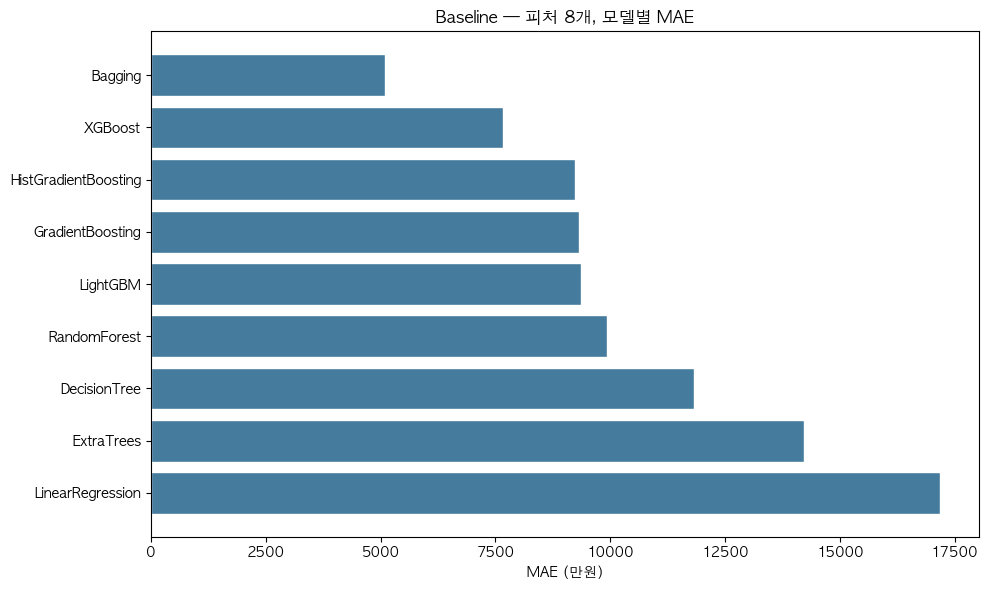

Baseline 1위: Bagging
MAE: 5,091 만원


In [15]:
plot_df = result_df.sort_values('MAE_만원', ascending=True)
plot_metrics_bars(
    plot_df, x_col='model',
    title=f'Baseline — 피처 {len(feature_cols)}개, 모델별 4지표 (test)',
    colors='#457b9d',
)

best = result_df.iloc[0]
print(f"Baseline 1위: {best['model']}")
print(format_metric_line(best))


## 7. 1위 모델 하이퍼파라미터 tuning

In [16]:
from sklearn.model_selection import RandomizedSearchCV

best_name = result_df.iloc[0]['model']
mae_before = result_df.iloc[0]['MAE_만원']

print('=== tuning 대상 ===')
print(f'모델: {best_name}')
print('튜닝 전:', format_metric_line(result_df.iloc[0]))


=== tuning 대상 ===
모델: Bagging
튜닝 전 MAE: 5,091 만원


In [17]:
tuning_table = {
    'HistGradientBoosting': (
        HistGradientBoostingRegressor(random_state=42), False,
        {
            'model__max_depth': [6, 8, 10, 12],
            'model__max_iter': [100, 200, 300],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__min_samples_leaf': [20, 50, 100],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [10, 14, 18, None],
            'model__min_samples_leaf': [10, 20, 50],
            'model__max_features': ['sqrt', 0.5, 0.8],
        }
    ),
    'ExtraTrees': (
        ExtraTreesRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [10, 14, 18, None],
            'model__min_samples_leaf': [10, 20, 50],
        }
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=42), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [4, 6, 8],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__min_samples_leaf': [20, 50],
        }
    ),
    'DecisionTree': (
        DecisionTreeRegressor(random_state=42), False,
        {
            'model__max_depth': [8, 12, 16, 20],
            'model__min_samples_leaf': [10, 20, 50, 100],
        }
    ),
    'LinearRegression': (
        LinearRegression(), True,
        {'model__fit_intercept': [True]},
    ),
    'Bagging': (
        BaggingRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [20, 30, 50],
            'model__max_samples': [0.7, 0.9, 1.0],
        }
    ),
}

try:
    from xgboost import XGBRegressor
    tuning_table['XGBoost'] = (
        XGBRegressor(n_jobs=-1, random_state=42, verbosity=0), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [6, 8, 10],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__subsample': [0.7, 0.9, 1.0],
        }
    )
except ImportError:
    pass

try:
    from lightgbm import LGBMRegressor
    tuning_table['LightGBM'] = (
        LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [6, 8, 10],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__num_leaves': [31, 63, 127],
        }
    )
except ImportError:
    pass

if best_name not in tuning_table:
    raise ValueError(f'{best_name} — tuning_table에 그리드 추가 필요')

base_model, use_scale, param_grid = tuning_table[best_name]

prep_steps = []
if feature_num:
    prep_steps.append(('num', StandardScaler() if use_scale else 'passthrough', feature_num))
if feature_cat:
    prep_steps.append(('cat', OneHotEncoder(handle_unknown='ignore'), feature_cat))

tune_pipe = Pipeline([
    ('prep', ColumnTransformer(prep_steps)),
    ('model', base_model),
])

print(f'탐색 조합 수: {np.prod([len(v) for v in param_grid.values()]):,.0f} (RandomizedSearchCV n_iter=20)')

탐색 조합 수: 9 (RandomizedSearchCV n_iter=20)


In [18]:
search = RandomizedSearchCV(
    tune_pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print(f'=== {best_name} tuning 시작 ===')
t0 = time.time()
search.fit(X_train, y_train)
print(f'소요: {time.time() - t0:.0f}초')

print('\n최적 파라미터:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

=== Bagging tuning 시작 ===
Fitting 3 folds for each of 9 candidates, totalling 27 fits
소요: 76초

최적 파라미터:
  model__n_estimators: 50
  model__max_samples: 1.0


=== tuning 전후 성능 (test, 만원 MAE) ===


,구분,MAE_만원,RMSE_만원,R2_log,MAE_개선_만원
0,튜닝 전 (기본),5091.0,11732.0,0.9355,NaN
1,튜닝 후 (최적),5045.0,11629.0,0.9367,46.0


MAE 5,091 → 5,045 만원  (+0.91%)


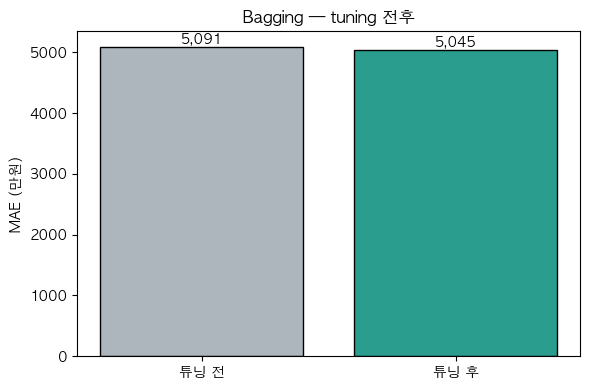

In [19]:
best_model = search.best_estimator_
pred_log = best_model.predict(X_test)
pred_won = np.expm1(pred_log)

metrics_after = eval_regression(y_won_test, pred_log, y_test)
metrics_before = {c: result_df.iloc[0][c] for c in METRIC_COLS}

compare = pd.DataFrame([
    {'구분': '튜닝 전 (기본)', **metrics_before},
    {'구분': '튜닝 후 (최적)', **metrics_after},
])
for col in METRIC_COLS:
    compare[f'{col}_개선'] = [np.nan, metrics_before[col] - metrics_after[col]]

print('=== tuning 전후 — 4지표 (test) ===')
display(round_metrics(compare, {f'{c}_개선': METRIC_ROUND[c] for c in METRIC_COLS}))
print_metrics_delta(metrics_before, metrics_after, '튜닝 개선:')

plot_metrics_bars(
    compare, x_col='구분',
    title=f'{best_name} — tuning 전후 4지표',
    colors=['#adb5bd', '#2a9d8f'],
)


## 8. 클러스터별 4지표 — 최종 모델 (야간광 클러스터별)


=== 클러스터별 MAE (튜닝 후 최적 모델) ===


,cluster_name,MAE_만원,건수
1,저광도,3028.0,31279
2,중광도,6247.0,21834
0,고광도,10389.0,6887


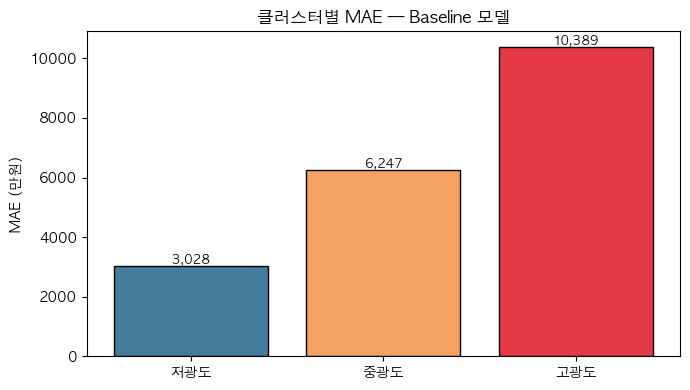

In [20]:
cluster_colors = {'고광도': '#e63946', '중광도': '#f4a261', '저광도': '#457b9d'}

err_df = build_err_df(
    y_won_test.values, pred_log, y_test.values,
    cluster_name=df.loc[X_test.index, 'cluster_name'].values,
)
cluster_stats = cluster_metrics(err_df)

print('=== 클러스터별 4지표 (튜닝 후 최적 모델 · test) ===')
display(round_metrics(cluster_stats, {'건수': 0}))

plot_cluster_metrics_2x2(
    cluster_stats,
    title=f'클러스터별 4지표 — Baseline 모델',
    cluster_colors=cluster_colors,
)


## 9. 풀 데이터셋 재학습

7번 `search.best_estimator_`로 **전체 239만건** 학습 · **MAE / RMSE / R²(log) / MAPE** 4지표 + 클러스터별 2×2 시각화

풀 데이터: 2,396,830건 (샘플링 없음)
train: 1,917,464 / test: 479,366
학습 소요: 99초
사용 파라미터: {'model__n_estimators': 50, 'model__max_samples': 1.0}

=== 풀 데이터 test — 4지표 ===


,MAE_만원,RMSE_만원,R2_log,MAPE_pct
0,2648.0,6387.0,0.9775,8.0



=== 클러스터별 4지표 (풀 데이터) ===


,cluster_name,MAE_만원,RMSE_만원,R2_log,MAPE_pct,건수
1,저광도,1620.0,3165.0,0.9731,7.9,250923.0
2,중광도,3302.0,7104.0,0.9713,7.9,173627.0
0,고광도,5286.0,12288.0,0.9737,8.5,54816.0


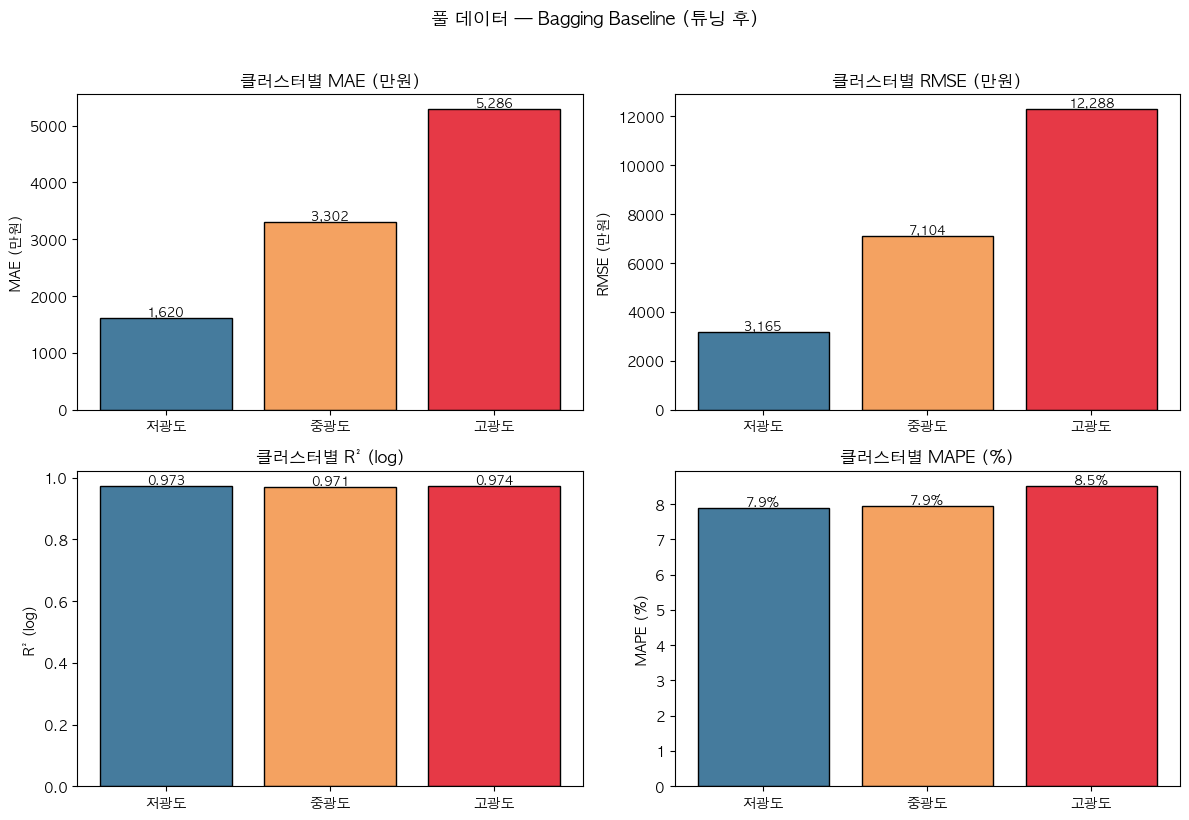

In [21]:
from sklearn.base import clone

df_full = pd.read_csv('apt_ml_ready.csv', encoding='utf-8-sig')
print(f'풀 데이터: {len(df_full):,}건 (샘플링 없음)')

X_all = df_full[feature_cols]
y_log_all = df_full['log_dealAmount_num']
y_won_all = df_full['dealAmount_num']

X_tr, X_te, y_tr, y_te, y_won_tr, y_won_te = train_test_split(
    X_all, y_log_all, y_won_all, test_size=0.2, random_state=42,
)
print(f'train: {len(X_tr):,} / test: {len(X_te):,}')

t0 = time.time()
full_model = clone(search.best_estimator_)
full_model.fit(X_tr, y_tr)
print(f'학습 소요: {time.time() - t0:.0f}초')
print('사용 파라미터:', search.best_params_)

pred_log = full_model.predict(X_te)
overall = eval_regression(y_won_te.values, pred_log, y_te.values)

print('\n=== 풀 데이터 test — 4지표 ===')
display(round_metrics(pd.DataFrame([overall])))

err_df = build_err_df(
    y_won_te.values, pred_log, y_te.values,
    cluster_name=df_full.loc[X_te.index, 'cluster_name'].values,
)
cluster_stats = cluster_metrics(err_df)

print('\n=== 클러스터별 4지표 (풀 데이터) ===')
display(round_metrics(cluster_stats, {'건수': 0}))

plot_cluster_metrics_2x2(
    cluster_stats,
    title='풀 데이터 — {best_name} (Baseline)',
    cluster_colors={'고광도': '#e63946', '중광도': '#f4a261', '저광도': '#457b9d'},
)


## 10. 발표용 요약 (4지표 CSV)


In [ ]:
rows = [
    presentation_row('11_baseline', '튜닝후_샘플', 'test', best_name, metrics_after, len(X_test)),
    presentation_row('11_baseline', '풀재학습', '풀_test', best_name, overall, len(X_te)),
]
for _, r in cluster_stats.iterrows():
    rows.append(presentation_row(
        '11_baseline', '풀재학습_클러스터', r['cluster_name'], best_name,
        {c: r[c] for c in METRIC_COLS}, int(r['건수']),
    ))

summary = save_presentation_summary(rows, notebook='11_baseline')
display(summary)
